# 02 — Feature Engineering

**Capstone 1 · SignalCraft · Track A: Flight Punctuality**

Everything in this notebook is written out in full. **Nothing is imported from a project module** —
each feature is built here, in front of you, with the reasoning next to it.

**Input:** `data/processed/flights_clean.parquet` (from notebook 01)
**Output:** `data/processed/flights_features.parquet` — 24 features ready for modelling

### The one rule everything obeys

The model runs **24 hours before departure**. For every feature, ask:

> *Would an airport duty manager know this value at 09:00 the day before the flight?*

If no, it is not a feature — however well it predicts. Getting this wrong is the single most common
way this assignment fails, because the columns that leak are also the most predictive ones.

---
## Step 0 — Setup and load

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

IN_PATH  = ROOT / 'data' / 'processed' / 'flights_clean.parquet'
OUT_PATH = ROOT / 'data' / 'processed' / 'flights_features.parquet'
print('input:', IN_PATH.name, '| exists:', IN_PATH.exists())

input: flights_clean.parquet | exists: True


In [2]:
t0 = time.time()
df = pd.read_parquet(IN_PATH)
print(f'{len(df):,} rows x {df.shape[1]} columns in {time.time() - t0:.0f}s')
print(f'positive rate (late): {df.label.mean():.4f}')
df.head(3)

6,896,283 rows x 25 columns in 2s
positive rate (late): 0.2242


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,OriginCityName,OriginState,Dest,DestCityName,DestState,CRSDepTime,DepTimeBlk,CRSArrTime,ArrTimeBlk,CRSElapsedTime,Distance,DistanceGroup,row_key,period,label
0,2025,3,7,23,3,2025-07-23,AA,N450AN,969,MIA,"Miami, FL",FL,CLT,"Charlotte, NC",NC,832,0800-0859,1042,1000-1059,130.0,650.0,3,2025-07-23|AA|969|MIA|CLT|832,2025-07,0
1,2025,3,7,24,4,2025-07-24,AA,N431AN,969,MIA,"Miami, FL",FL,CLT,"Charlotte, NC",NC,832,0800-0859,1042,1000-1059,130.0,650.0,3,2025-07-24|AA|969|MIA|CLT|832,2025-07,1
2,2025,3,7,25,5,2025-07-25,AA,N444UW,969,MIA,"Miami, FL",FL,CLT,"Charlotte, NC",NC,832,0800-0859,1042,1000-1059,130.0,650.0,3,2025-07-25|AA|969|MIA|CLT|832,2025-07,0


---
## Step 1 — The forbidden list

Before building anything, write down what may **never** appear in a feature matrix, and make it a
check the code runs rather than a promise you remember.

These 28 columns describe what happened *during or after* the flight. They were never downloaded, so
this assertion should always pass — but it stays in the code because it costs nothing and it will
catch the day someone helpfully re-adds a column.

In [3]:
FORBIDDEN = frozenset({
    # actual departure - known only at pushback
    'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups',
    # in-flight
    'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'AirTime', 'ActualElapsedTime',
    # arrival - this IS the answer
    'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups', 'ArrDel15',
    # why it was late - decided afterwards
    'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
    # outcome flags
    'Cancelled', 'CancellationCode', 'Diverted', 'DivAirportLandings',
    'FirstDepTime', 'TotalAddGTime', 'LongestAddGTime',
})

def assert_no_leakage(frame):
    """Raise if any post-prediction-time column reached the feature matrix."""
    leaked = FORBIDDEN & set(frame.columns)
    if leaked:
        raise ValueError(f'LEAKAGE: {sorted(leaked)} are not known 24h before departure')
    print(f'no leakage - checked {len(FORBIDDEN)} forbidden columns against {frame.shape[1]}')

assert_no_leakage(df)

no leakage - checked 28 forbidden columns against 25


### Why `DepDelay` would be so tempting

If we kept it, the model would score around 0.95 and be worthless. Knowing a flight *left* 40
minutes late tells you it will *arrive* late — that is arithmetic, not prediction, and the
information does not exist when the decision is actually made.

---
## Step 2 — Schedule features

The safe group. Everything here comes from the published timetable, which exists months ahead.

### 2a. Departure hour

`CRSDepTime` is an integer: `1649` means 16:49. Integer-divide by 100 to get the hour.

**The `% 24` matters.** The data writes midnight as `2400`, and `2400 // 100` is 24 — an hour that
does not exist. Without the modulo you create a phantom 25th hour with strange statistics.

**Why it should predict:** delay accumulates through the operating day. The network starts each
morning clean.

In [4]:
crs = df.CRSDepTime.astype(int)
df['dep_hour'] = (crs // 100) % 24
df['dep_minute_of_day'] = df.dep_hour * 60 + (crs % 100)

print(df.groupby('dep_hour').label.mean().round(4).to_string())

dep_hour
0     0.1667
1     0.1835
2     0.2145
3     0.1985
4     0.1812
5     0.0832
6     0.0987
7     0.1255
8     0.1443
9     0.1620
10    0.1774
11    0.1970
12    0.2161
13    0.2322
14    0.2613
15    0.2772
16    0.2988
17    0.3090
18    0.3208
19    0.3246
20    0.3230
21    0.2936
22    0.2838
23    0.1979


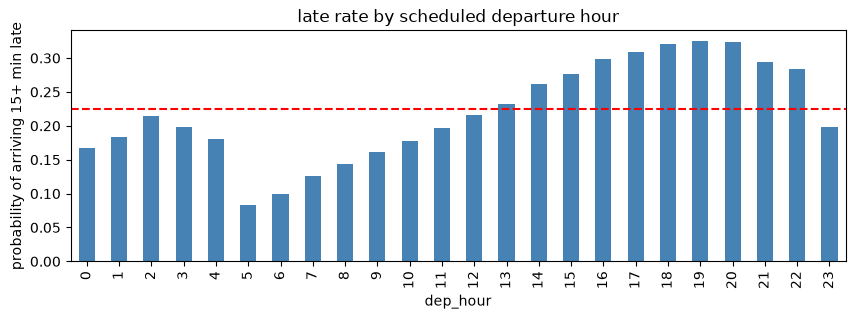

In [5]:
df.groupby('dep_hour').label.mean().plot(
    kind='bar', figsize=(10, 3), color='steelblue', title='late rate by scheduled departure hour')
plt.axhline(df.label.mean(), ls='--', c='red')
plt.ylabel('probability of arriving 15+ min late')
plt.show()

**8% late at 05:00 against 32% at 19:00** — the strongest single pattern in this dataset, and the
reason `dep_hour` is the first feature built.

The fall after 20:00 is survivorship: only long-haul and overnight flights remain, departing from
airports that have already quietened down.

### 2b. Arrival hour

**Why:** congestion at the *destination* causes holding and gate waits. That is a different
mechanism from departure congestion, so it deserves its own feature.

In [6]:
df['arr_hour'] = (df.CRSArrTime.astype(int) // 100) % 24
print(df.groupby('arr_hour').label.mean().round(3).tail(8).to_string())

arr_hour
16    0.243
17    0.272
18    0.301
19    0.304
20    0.312
21    0.320
22    0.313
23    0.315


### 2c. Red-eye and weekend flags

**Red-eye:** an overnight departure starts from a network that has been idle for hours, so it
inherits almost no accumulated delay.

**Weekend:** a different traffic mix — leisure rather than business.

In [7]:
df['is_red_eye'] = df.dep_hour.between(0, 5).astype('int8')
df['is_weekend'] = df.DayOfWeek.isin([6, 7]).astype('int8')

print('red-eye share :', f'{df.is_red_eye.mean():.1%}', '| late rate:',
      f'{df.loc[df.is_red_eye == 1, "label"].mean():.4f}')
print('weekend share :', f'{df.is_weekend.mean():.1%}', '| late rate:',
      f'{df.loc[df.is_weekend == 1, "label"].mean():.4f}')
print('\nlate rate by day of week (1=Mon):')
print(df.groupby('DayOfWeek').label.mean().round(4).to_string())

red-eye share : 3.0% | late rate: 0.0904
weekend share : 27.8% | late rate: 0.2413

late rate by day of week (1=Mon):
DayOfWeek
1    0.2384
2    0.1874
3    0.1929
4    0.2305
5    0.2345
6    0.2144
7    0.2649


**Sunday is the worst day and Tuesday the best** — not Friday, which is the intuitive guess.

Note this makes `is_weekend` a weak feature: it merges Saturday (mid-pack) with Sunday (worst).
`DayOfWeek` itself carries more information. We keep both and let feature selection decide.

### 2d. Scheduled speed — the schedule-padding proxy

`Distance / CRSElapsedTime` gives implied average speed.

**Why it should predict:** an airline that wants good punctuality statistics pads its block times.
That padding shows up here as a *lower* implied speed. It captures airline scheduling behaviour that
raw distance cannot.

In [8]:
df['sched_speed_mph'] = df.Distance / (df.CRSElapsedTime / 60.0)
print(df.sched_speed_mph.describe().round(1).to_string())

count    6896280.0
mean         306.1
std           85.5
min            2.2
25%          248.6
50%          315.1
75%          367.8
max         4813.3


### Clip the physically impossible values

Notebook 01 found a scheduled flight time of **-60 minutes** in the source data. Anything derived
from it is nonsense. A decision tree will happily build a rule around forty corrupt rows, so bound
the feature to a physically sensible range.

In [9]:
before_min, before_max = df.sched_speed_mph.min(), df.sched_speed_mph.max()
df['sched_speed_mph'] = df.sched_speed_mph.clip(100, 700)
print(f'before clipping: {before_min:.0f} to {before_max:.0f} mph')
print(f'after clipping : {df.sched_speed_mph.min():.0f} to {df.sched_speed_mph.max():.0f} mph')

before clipping: 2 to 4813 mph
after clipping : 100 to 700 mph


### 2e. Holiday proximity

**Why:** Thanksgiving and Christmas load the network beyond what the schedule assumes.
**Available at T-24h:** yes — the calendar is known years ahead.

In [10]:
HOLIDAYS = pd.to_datetime([
    '2025-07-04', '2025-09-01', '2025-11-27', '2025-11-28', '2025-12-24',
    '2025-12-25', '2025-12-31', '2026-01-01', '2026-01-19', '2026-02-16', '2026-05-25',
])

dates = df.FlightDate.to_numpy(dtype='datetime64[ns]')
gaps = np.abs(dates[:, None] - HOLIDAYS.to_numpy(dtype='datetime64[ns]')[None, :])
df['days_to_holiday'] = (gaps.min(axis=1) / np.timedelta64(1, 'D')).clip(0, 7)
df['is_holiday_window'] = (df.days_to_holiday <= 2).astype('int8')

print('holiday-window share:', f'{df.is_holiday_window.mean():.1%}')
print(df.groupby('is_holiday_window').label.mean().round(4).to_string())

holiday-window share: 11.3%
is_holiday_window
0    0.2227
1    0.2359


---
## Step 3 — Congestion features

How busy is the airport at that moment? Counted from the **timetable**, so no outcome is involved
and there is no leak.

In [11]:
t0 = time.time()
bank = (df.groupby(['FlightDate', 'Origin', 'dep_hour'], observed=True)
          .size().rename('origin_bank_size'))
df = df.merge(bank, on=['FlightDate', 'Origin', 'dep_hour'], how='left')

arrivals = (df.groupby(['FlightDate', 'Dest', 'arr_hour'], observed=True)
              .size().rename('dest_bank_size'))
df = df.merge(arrivals, on=['FlightDate', 'Dest', 'arr_hour'], how='left')

print(f'built in {time.time() - t0:.0f}s')
print(df[['origin_bank_size', 'dest_bank_size']].describe().round(1).to_string())

built in 17s
       origin_bank_size  dest_bank_size
count         6896283.0       6896283.0
mean               23.7            23.0
std                20.8            21.2
min                 1.0             1.0
25%                 7.0             6.0
50%                19.0            17.0
75%                33.0            31.0
max               106.0           114.0


### A feature that will turn out to be useless — and why that is worth knowing

The reasoning was plausible: more departures per hour means more pressure on runways, gates and
ground crew. Later analysis shows **`origin_bank_size` has essentially zero mutual information with
the label.**

The reason: **a raw count is not congestion.** 100 departures an hour at Atlanta is a normal
Tuesday; 40 at a regional airport is chaos. The feature needed dividing by each airport's own
typical capacity, and it does not.

Keep it, report that it failed, and say why. A well-reasoned feature that does not work is a finding
— quietly deleting it is not.

---
## Step 4 — Aircraft rotation

Which leg of the aircraft's day is this?

**Why it should predict:** the fourth flight of an aircraft's day inherits every delay from the
first three. This is the mechanism behind the industry's own "late aircraft" delay category.

**Available at T-24h:** yes — the rotation is published in the schedule.

In [12]:
t0 = time.time()
has_tail = df.Tail_Number.notna() & df.Tail_Number.ne('')
ordered = df.loc[has_tail].sort_values(['Tail_Number', 'FlightDate', 'dep_minute_of_day'])
leg = ordered.groupby(['Tail_Number', 'FlightDate'], observed=True).cumcount() + 1

df['tail_leg_number'] = pd.Series(leg, index=ordered.index).reindex(df.index)
df['tail_leg_number'] = df.tail_leg_number.fillna(1).astype('int16')

print(f'built in {time.time() - t0:.0f}s | max legs in a day: {df.tail_leg_number.max()}')
print(df.groupby(df.tail_leg_number.clip(1, 8)).label.agg(['mean', 'size']).round(4).to_string())

built in 48s | max legs in a day: 17
                   mean     size
tail_leg_number                 
1                0.1429  1738528
2                0.1990  1599471
3                0.2414  1354503
4                0.2814  1056994
5                0.3094   624018
6                0.3070   367464
7                0.3338   100325
8                0.2838    54980


**Leg 1 is much safer than leg 6.** The pattern is real and monotonic.

But be careful: later analysis shows `tail_leg_number` correlates **0.76** with `dep_hour` — later
legs simply happen later in the day. Most of its apparent value is already captured by the clock.

---
## Step 5 — History features, and the trap inside them

This is where the project can quietly fail.

### The wrong way

```python
df['route_late_rate'] = df.groupby('route').label.transform('mean')   # DO NOT DO THIS
```

A route's average over the whole dataset **includes flights that had not happened yet** when the
prediction was made. A March flight would be scored using June's outcomes.

It is seductive because it produces a great validation score and looks like ordinary feature
engineering rather than cheating.

### The right way

Compute an **expanding average over strictly earlier months**. A row in March sees July through
February and nothing else. We do this by aggregating to (group, month), taking a running total in
date order, then **shifting by one month** so a month never contributes to its own rate.

In [13]:
df['period'] = df.FlightDate.dt.to_period('M')
df['route'] = df.Origin.astype(str) + '-' + df.Dest.astype(str)
df['carrier_origin'] = df.Reporting_Airline.astype(str) + '@' + df.Origin.astype(str)

GLOBAL_PRIOR = float(df.label.mean())
SMOOTHING = 20.0
print(f'global prior late rate: {GLOBAL_PRIOR:.4f}')

global prior late rate: 0.2242


### Smoothing: why a route with 3 flights should not be believed

A route with three prior flights, two of them late, has an observed rate of 0.67. Trusting that is
how a model learns noise.

**Additive smoothing** pulls thin groups toward the global average:

```
rate = (late_count + 20 x prior) / (total_count + 20)
```

`20` means "start trusting this group's own history once it has substantially more than 20 flights".
The typical route here has ~477 flights, so most are barely shrunk — only the thin tail is.

In [14]:
def expanding_rate(frame, keys, name):
    """Late-rate for `keys`, using strictly earlier months only. Fold-safe by construction."""
    g = (frame.groupby([*keys, 'period'], observed=True)['label']
              .agg(['sum', 'count']).reset_index().sort_values('period'))

    g['cum_late'] = g.groupby(keys, observed=True)['sum'].cumsum()
    g['cum_n']    = g.groupby(keys, observed=True)['count'].cumsum()

    # shift by one period: a month never sees its own outcomes
    g['prior_late'] = g.groupby(keys, observed=True)['cum_late'].shift(1)
    g['prior_n']    = g.groupby(keys, observed=True)['cum_n'].shift(1)

    g[name] = ((g.prior_late.fillna(0) + SMOOTHING * GLOBAL_PRIOR)
               / (g.prior_n.fillna(0) + SMOOTHING))
    g[f'{name}_n'] = g.prior_n.fillna(0)
    return g[[*keys, 'period', name, f'{name}_n']]

print('helper defined')

helper defined


In [15]:
t0 = time.time()
SPECS = [
    (['route'],                'route_late_rate'),
    (['Reporting_Airline'],    'carrier_late_rate'),
    (['Origin'],               'origin_late_rate'),
    (['Dest'],                 'dest_late_rate'),
    (['carrier_origin'],       'carrier_origin_late_rate'),
    (['Origin', 'dep_hour'],   'origin_hour_late_rate'),
]

for keys, name in SPECS:
    table = expanding_rate(df, keys, name)
    df = df.merge(table, on=[*keys, 'period'], how='left')
    df[name] = df[name].fillna(GLOBAL_PRIOR)
    print(f'  {name:28} range {df[name].min():.3f} - {df[name].max():.3f}')

print(f'\nbuilt 6 history features in {time.time() - t0:.0f}s')

  route_late_rate              range 0.029 - 0.696
  carrier_late_rate            range 0.156 - 0.360
  origin_late_rate             range 0.029 - 0.533
  dest_late_rate               range 0.037 - 0.488
  carrier_origin_late_rate     range 0.029 - 0.645
  origin_hour_late_rate        range 0.024 - 0.704

built 6 history features in 24s


### The cost of only looking backwards

The first month has no earlier data, so its rows fall back to the global average. Measure it — this
is why cross-validation cannot start at month 1.

In [16]:
coverage = (df.route_late_rate_n > 0).mean()
print(f'rows with real prior history: {coverage:.2%}')
print(f'rows falling back to the global prior: {1 - coverage:.2%}')
print('\n=> the first ~4 months are training-only; validation starts after that')

rows with real prior history: 90.96%
rows falling back to the global prior: 9.04%

=> the first ~4 months are training-only; validation starts after that


### Why keep the *count* as a feature too

`route_late_rate_n` tells the model **how much to trust its own rate feature**. A rate of 0.6 backed
by 3 flights and one backed by 3,000 are very different pieces of evidence, and a tree can learn to
discount the first.

All three feature-selection methods in `04_Features_And_Selection.md` keep this feature. The
meta-feature earns its place.

In [17]:
print(df.route_late_rate_n.describe().round(0).to_string())

count    6896283.0
mean        1228.0
std         1378.0
min            0.0
25%          267.0
50%          762.0
75%         1703.0
max        10103.0


---
## Step 6 — Assemble the feature matrix

In [18]:
FEATURES = [
    # raw schedule
    'Distance', 'CRSElapsedTime', 'DayOfWeek', 'Month', 'Quarter', 'DistanceGroup',
    # derived schedule
    'dep_hour', 'dep_minute_of_day', 'arr_hour', 'is_red_eye', 'is_weekend',
    'sched_speed_mph', 'days_to_holiday', 'is_holiday_window',
    # congestion and rotation
    'origin_bank_size', 'dest_bank_size', 'tail_leg_number',
    # backward-looking history
    'route_late_rate', 'carrier_late_rate', 'origin_late_rate', 'dest_late_rate',
    'carrier_origin_late_rate', 'origin_hour_late_rate', 'route_late_rate_n',
]
CATEGORICALS = ['Reporting_Airline', 'Origin', 'Dest']

print(f'{len(FEATURES)} numeric features + {len(CATEGORICALS)} categorical')
X = df[FEATURES]
assert_no_leakage(X)

24 numeric features + 3 categorical
no leakage - checked 28 forbidden columns against 24


---
## Step 7 — How each feature relates to the label

Two measures, because they answer different questions.

In [19]:
corr = X.corrwith(df.label).sort_values(key=abs, ascending=False)
print('Pearson correlation with the label:')
print(corr.round(4).to_string())

Pearson correlation with the label:
origin_hour_late_rate       0.1756
dep_minute_of_day           0.1738
dep_hour                    0.1735
arr_hour                    0.1542
tail_leg_number             0.1360
route_late_rate             0.1020
carrier_origin_late_rate    0.0946
is_red_eye                 -0.0561
origin_late_rate            0.0512
dest_late_rate              0.0483
carrier_late_rate           0.0317
origin_bank_size            0.0311
DayOfWeek                   0.0301
is_weekend                  0.0255
days_to_holiday            -0.0141
route_late_rate_n           0.0139
is_holiday_window           0.0101
sched_speed_mph             0.0094
CRSElapsedTime              0.0092
Month                       0.0088
Quarter                     0.0071
Distance                    0.0066
DistanceGroup               0.0062
dest_bank_size             -0.0016


### Read that honestly

**The strongest feature correlates 0.176 with the label.** Nothing is close to 0.3.

That is the real shape of this problem. Predicting a stochastic outcome 24 hours ahead, without
weather and without knowing what will go wrong upstream, is genuinely hard.

**If any correlation had come back at 0.8, the right response would be to hunt for a leak — not to
celebrate.**

### Pearson only sees straight lines

`dep_hour` climbs to 19:00 then falls. Pearson under-reports curved relationships. **Mutual
information** detects any kind of dependence, so compute it too — on a sample, since it is slow.

In [20]:
from sklearn.feature_selection import mutual_info_classif

sample = X.sample(60_000, random_state=0)
mi_values = mutual_info_classif(sample.fillna(0), df.label.loc[sample.index], random_state=0)
mi = pd.Series(mi_values, index=X.columns).sort_values(ascending=False)
print('mutual information with the label:')
print(mi.round(5).to_string())

mutual information with the label:
origin_hour_late_rate       0.02742
dep_hour                    0.02198
dep_minute_of_day           0.02082
arr_hour                    0.01729
tail_leg_number             0.01344
carrier_origin_late_rate    0.01173
route_late_rate             0.01054
sched_speed_mph             0.01007
Month                       0.00830
dest_late_rate              0.00805
origin_late_rate            0.00777
carrier_late_rate           0.00636
DistanceGroup               0.00426
route_late_rate_n           0.00399
Distance                    0.00379
dest_bank_size              0.00232
days_to_holiday             0.00230
CRSElapsedTime              0.00177
is_red_eye                  0.00120
is_weekend                  0.00117
Quarter                     0.00064
DayOfWeek                   0.00024
origin_bank_size            0.00000
is_holiday_window           0.00000


In [21]:
compare = pd.DataFrame({
    'pearson_rank': corr.abs().rank(ascending=False).astype(int),
    'mi_rank': mi.rank(ascending=False).astype(int),
})
compare['moved'] = compare.pearson_rank - compare.mi_rank
compare.sort_values('moved', key=abs, ascending=False).head(6)

,pearson_rank,mi_rank,moved
Month,20,9,11
is_red_eye,8,19,-11
origin_bank_size,12,23,-11
DistanceGroup,23,13,10
sched_speed_mph,18,8,10
DayOfWeek,13,22,-9


**Four features change rank substantially**, and each tells you something:

- `sched_speed_mph` and `Month` rise sharply — their relationship with lateness is **curved**, so
  Pearson nearly discarded two useful features.
- `DayOfWeek` falls hard — Pearson was reading a meaningless numeric ordering of day codes.
- `origin_bank_size` sits at the bottom of both. Confirmed useless, as predicted in Step 3.

### Redundancy — how much do the features repeat each other?

In [22]:
cm = X.fillna(0).corr().abs()
pairs = (cm.where(np.triu(np.ones(cm.shape), 1).astype(bool))
           .stack().sort_values(ascending=False))
print('feature pairs correlated above 0.7:')
print(pairs[pairs > 0.7].round(3).to_string())

feature pairs correlated above 0.7:
dep_hour           dep_minute_of_day           0.998
Distance           DistanceGroup               0.987
                   CRSElapsedTime              0.983
CRSElapsedTime     DistanceGroup               0.971
Month              Quarter                     0.970
days_to_holiday    is_holiday_window           0.856
DistanceGroup      sched_speed_mph             0.848
Distance           sched_speed_mph             0.843
DayOfWeek          is_weekend                  0.784
CRSElapsedTime     sched_speed_mph             0.780
dep_minute_of_day  tail_leg_number             0.761
dep_hour           tail_leg_number             0.760
                   origin_hour_late_rate       0.729
dep_minute_of_day  origin_hour_late_rate       0.728
origin_late_rate   carrier_origin_late_rate    0.718


**`dep_hour` and `dep_minute_of_day` correlate 0.998** — they are effectively one feature.

This matters for two reasons. A linear model given near-identical inputs produces unstable
coefficients, which makes it hard to explain. And a plain "rank by relevance" selection would take
all four distance features and learn the same thing four times.

That is the argument for the selection methods in `04_Features_And_Selection.md`.

---
## Step 8 — Save

In [23]:
keep = ['FlightDate', 'row_key', 'label', 'period', 'route',
        *CATEGORICALS, *FEATURES]
out = df[keep].copy()
out['period'] = out.period.astype(str)

out.to_parquet(OUT_PATH, index=False, compression='snappy')
print(f'saved: {OUT_PATH.relative_to(ROOT)}')
print(f'size : {OUT_PATH.stat().st_size / 1e6:,.0f} MB')
print(f'shape: {out.shape}')

saved: data\processed\flights_features.parquet
size : 165 MB
shape: (6896283, 32)


In [24]:
out.head(3)

,FlightDate,row_key,label,period,route,Reporting_Airline,Origin,Dest,Distance,CRSElapsedTime,DayOfWeek,Month,Quarter,DistanceGroup,dep_hour,dep_minute_of_day,arr_hour,is_red_eye,is_weekend,sched_speed_mph,days_to_holiday,is_holiday_window,origin_bank_size,dest_bank_size,tail_leg_number,route_late_rate,carrier_late_rate,origin_late_rate,dest_late_rate,carrier_origin_late_rate,origin_hour_late_rate,route_late_rate_n
0,2025-07-23,2025-07-23|AA|969|MIA|CLT|832,0,2025-07,MIA-CLT,AA,MIA,CLT,650.0,130.0,3,7,3,3,8,512,10,0,0,300.0,7.0,0,25,53,1,0.224186,0.224186,0.224186,0.224186,0.224186,0.224186,0.0
1,2025-07-24,2025-07-24|AA|969|MIA|CLT|832,1,2025-07,MIA-CLT,AA,MIA,CLT,650.0,130.0,4,7,3,3,8,512,10,0,0,300.0,7.0,0,26,53,1,0.224186,0.224186,0.224186,0.224186,0.224186,0.224186,0.0
2,2025-07-25,2025-07-25|AA|969|MIA|CLT|832,0,2025-07,MIA-CLT,AA,MIA,CLT,650.0,130.0,5,7,3,3,8,512,10,0,0,300.0,7.0,0,25,53,1,0.224186,0.224186,0.224186,0.224186,0.224186,0.224186,0.0


---
## Summary

| | |
|---|---|
| **Input** | `flights_clean.parquet` — 6,896,283 rows |
| **Built** | 24 features, 18 of them derived |
| **Output** | `flights_features.parquet` |

### The four things this notebook decided

1. **Every feature must be knowable 24 hours ahead.** The check is code, not a comment.
2. **History features look only backwards.** An expanding average shifted by one month is safe by
   construction — no need to recompute it inside every validation fold.
3. **Thin groups are smoothed toward the global average.** A 3-flight route is not evidence.
4. **Clip physically impossible values.** A scheduled speed of -296 mph would become a decision rule.

### What we already know will not work

- `origin_bank_size` — a raw count is not congestion
- `is_holiday_window` — nearly zero mutual information
- `is_weekend` — merges Saturday and Sunday, which behave differently

Reporting these is part of the assignment. A feature that failed for an understandable reason is a
finding.

### What comes next

Read **`04_Features_And_Selection.md`** for the three selection methods and how they disagree.

Then run **`03_model_build.ipynb`**, which trains the model, evaluates it and exports the pickle.